In [13]:
# Let's use the Beta Calculation code part
# Merge the BM, Factor Indicies, and Equities datasets

# 1. Load our datasets 
# Pro-tip: parse_dates ensures Python treats your 'Date' column as actual time objects
df_equity_1 = pd.read_csv('All_Equities_Cleaned.csv', parse_dates=['Dates'])
df_equity_2 = pd.read_csv('Equities_Jabbir.csv', parse_dates=['Dates'])
df_market = pd.read_csv('MSCI_Data.csv', parse_dates=['Date'])

# 2. Set the Date as the index to make alignment easier
df_equity_1.set_index('Dates', inplace=True)
df_equity_2.set_index('Dates', inplace=True)
df_market.set_index('Date', inplace=True)

# 3. Merge them into one master dataframe
# We join on the index (the dates)
df_merged = df_market.join([df_equity_1, df_equity_2], how='inner')

# Take a peek at the result
print(df_merged.head())

returns = df_merged.pct_change()

# Beta Calculation

# 1. Define our targets (Benchmark + Factors)
targets = [
    'MSCI USA',
    'MSCI USA Value', 'MSCI USA Low Size', 'MSCI USA Low Volatility', 
    'MSCI USA High Dividend Yield', 'MSCI USA Quality', 'MSCI USA Momentum'
]

# Identify equity columns (everything in the dataframe that isn't a target or the risk-free rate)
# Make sure to adjust 'RF_Rate' if your column is named differently or already dropped
equities = [col for col in returns.columns if col not in targets]

# 2. Calculate the 60-month rolling variance for ALL targets at once
rolling_vars = returns[targets].rolling(window=60).var()

# 3. Create a dictionary to store the results
all_equities_betas = {}

# 4. Loop through each equity to calculate its specific Betas
for equity in equities:
    # Create an empty DataFrame to store this equity's betas
    equity_betas = pd.DataFrame(index=returns.index)
    
    for target in targets:
        # Calculate rolling covariance between the equity and the target
        rolling_cov = returns[equity].rolling(window=60).cov(returns[target])
        
        # Calculate Beta: Rolling Covariance / Rolling Variance of the target
        equity_betas[f'Beta_{target}'] = rolling_cov / rolling_vars[target]
        
    # Drop the initial 59 months with NaN
    equity_betas.dropna(inplace=True)
    
    # Store the completed DataFrame in our dictionary
    all_equities_betas[equity] = equity_betas



            MSCI USA  MSCI USA Value  MSCI USA Low Size  \
1999-01-29   2673.05     3277.734545            2384.21   
1999-02-26   2598.02     3251.106568            2391.18   
1999-03-31   2705.67     3332.419537            2344.66   
1999-04-30   2802.00     3624.972158            2410.24   
1999-05-31   2736.32     3560.597835            2663.08   

            MSCI USA Low Volatility  MSCI USA High Dividend Yield  \
1999-01-29               995.479542                    997.649417   
1999-02-26               969.079546                    970.419053   
1999-03-31               989.782505                    967.408227   
1999-04-30              1033.753199                   1064.030284   
1999-05-31              1024.310711                   1045.278656   

            MSCI USA Quality  MSCI USA Momentum  KATE US Equity  \
1999-01-29        683.831934         512.942863         19.0938   
1999-02-26        658.588413         500.178311         16.8438   
1999-03-31        682.563547 

C:\Users\Anas\AppData\Local\Temp\ipykernel_39592\452669178.py:23: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df_merged.pct_change()


In [2]:
# Let's Load Libraries for the opti part
import numpy as np
import pandas as pd
from scipy.optimize import minimize


In [28]:
# Let's load the datasets
df_rf=pd.read_csv('10Yrs_Yield_unadjusted.csv', parse_dates=['observation_date'])
df_constituents=pd.read_csv('sp500_ticker_history.csv')
df_rf['DATE'] = pd.to_datetime(df_rf['observation_date'])

# 2. Set it as the index
df_rf.set_index('DATE', inplace=True)

# 3. Sort the index (Forward-filling requires the dates to be in chronological order!)
df_rf.sort_index(inplace=True)

In [10]:
# Let's adjust our constituents dataset
def format_quarter(q_str):
    try:
        q, year = q_str.split(' ')
        return pd.Period(f"{year}{q}", freq='Q')
    except:
        return pd.NaT

df_constituents['Start_Q'] = df_constituents['Earliest_Quarter'].apply(format_quarter)
df_constituents['End_Q'] = df_constituents['Latest_Quarter'].apply(format_quarter)

# 1. FIX THE ANOMALIES: Swap dates if Start > End
mask_inverted = df_constituents['Start_Q'] > df_constituents['End_Q']
if mask_inverted.any():
    print(f"Fixing {mask_inverted.sum()} rows where Earliest_Quarter > Latest_Quarter")
    # Temporarily store the start dates
    temp_start = df_constituents.loc[mask_inverted, 'Start_Q']
    # Swap them
    df_constituents.loc[mask_inverted, 'Start_Q'] = df_constituents.loc[mask_inverted, 'End_Q']
    df_constituents.loc[mask_inverted, 'End_Q'] = temp_start

# 2. TRANSFORM TO DICTIONARY
# Let's say we want to check constituents for these specific rebalance dates
# (Make sure these dates match the ones in your quarterly_dates loop)
rebalance_dates = pd.date_range(start='2000-03-31', end='2019-12-31', freq='Q')

sp500_constituents = {}

for date in rebalance_dates:
    # Convert our target date to a pandas quarter for easy comparison
    target_q = pd.Period(date, freq='Q')
    
    # Filter for stocks where the target quarter is between their start and end dates (inclusive)
    active_mask = (df_constituents['Start_Q'] <= target_q) & (df_constituents['End_Q'] >= target_q)
    
    # Get the list of active identifiers for this quarter
    active_tickers = df_constituents.loc[active_mask, 'Ticker_Value'].tolist()
    
    # Store in our dictionary
    sp500_constituents[date] = active_tickers

print(f"Constituents for 2010-03-31: {len(sp500_constituents[pd.Timestamp('2010-03-31')])} stocks")

Fixing 935 rows where Earliest_Quarter > Latest_Quarter
Constituents for 2010-03-31: 475 stocks


C:\Users\Anas\AppData\Local\Temp\ipykernel_39592\972303406.py:25: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rebalance_dates = pd.date_range(start='2000-03-31', end='2019-12-31', freq='Q')


In [34]:
# Let's set-up the optimization function
def beta_optimizer(
    date_t, constituents, returns_df, betas_dict, rf_df,
    bab_scenario=True, gross_exposure=2.0, net_exposure=0.0
):
    # 1. BULLETPROOF FORWARD DATES
    # Find the exact row index for the most recent trading day on or before date_t
    past_dates = returns_df.index[returns_df.index <= date_t]
    if len(past_dates) == 0:
        return None, None
        
    idx_t = returns_df.index.get_loc(past_dates[-1])
    
    # Grab exactly the next 3 rows (months) based on integer positioning
    if idx_t + 3 >= len(returns_df.index):
        return None, None
        
    forward_dates = returns_df.index[idx_t+1 : idx_t+4]

    # Filter constituents
    valid_tickers = [
        tic for tic in constituents 
        if tic in returns_df.columns 
        and returns_df[tic].loc[:date_t].count() >= 60
        and returns_df[tic].loc[forward_dates].count() == 3
    ]
    
    if not valid_tickers:
        print(f"{date_t.date()}: Skipped - No valid tickers with enough history.")
        return None, None

    # 2. Setup Data Inputs
    forward_returns = (1 + returns_df.loc[forward_dates, valid_tickers]).prod() - 1
    cov_matrix = returns_df.loc[:date_t].tail(60)[valid_tickers].cov() * 12
    
    forward_rates = rf_df['DGS10'].reindex(forward_dates, method='ffill')
    rf_forward = (1 + (forward_rates / 100 / 12)).prod() - 1

    current_betas = {}
    for tic in valid_tickers:
        current_betas[tic] = betas_dict[tic].loc[:date_t].iloc[-1]

    def negative_forward_sharpe(w):
        port_return = np.dot(w, forward_returns)
        port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) 
        return -(port_return - rf_forward) / (port_vol + 1e-9)

    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - net_exposure},
        {'type': 'ineq', 'fun': lambda w: gross_exposure - np.sum(np.abs(w))}
    ]
    
    bounds = []
    long_idx = []
    short_idx = []
    
    for i, tic in enumerate(valid_tickers):
        beta_market = current_betas[tic]['Beta_MSCI USA']
        if bab_scenario:
            if beta_market < 1.0:
                bounds.append((0.0, gross_exposure))
                long_idx.append(i)
            else:
                bounds.append((-gross_exposure, 0.0))
                short_idx.append(i)
        else:
            bounds.append((-gross_exposure, gross_exposure))

    # 3. SMART INITIAL GUESS
    # Prevent the optimizer from starting at 0.0 to avoid np.abs() gradient failures
    init_guess = np.zeros(len(valid_tickers))
    if bab_scenario and len(long_idx) > 0 and len(short_idx) > 0:
        # Start exactly at a feasible point (100% long side, 100% short side)
        init_guess[long_idx] = 1.0 / len(long_idx)
        init_guess[short_idx] = -1.0 / len(short_idx)
    else:
        init_guess.fill(net_exposure / len(valid_tickers))

    # 4. Run Optimizer
    result = minimize(
        negative_forward_sharpe, init_guess, method='SLSQP', 
        bounds=bounds, constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-6}
    )
    
    # We added print statements here so it doesn't fail silently anymore!
    if not result.success:
        print(f"{date_t.date()}: Optimization Failed - {result.message}")
        return None, None
        
    optimal_weights = pd.Series(result.x, index=valid_tickers)
    
    portfolio_betas = {}
    factor_cols = current_betas[valid_tickers[0]].index 
    for factor in factor_cols:
        port_beta = sum(optimal_weights[tic] * current_betas[tic][factor] for tic in valid_tickers)
        portfolio_betas[f'Port_{factor}'] = port_beta

    return optimal_weights, pd.Series(portfolio_betas)

In [41]:
# Rebalancing dates
quarterly_dates = pd.date_range(start='2004-01-31', end='2019-09-30', freq='Q')

# Create lists to hold our target data
target_weights_list = []
target_betas_list = []

# Loop through your quarterly rebalance dates
for date in quarterly_dates:
    weights, port_betas = beta_optimizer(
        date_t=date, 
        constituents=sp500_constituents[date], 
        returns_df=returns, 
        betas_dict=all_equities_betas, 
        rf_df=df_rf,
        bab_scenario=True, # Toggle True/False based on your desired dataset
        gross_exposure=1.6, 
        net_exposure=0.6
    )
    
    if weights is not None:
        # Tag the date so we can merge it with our feature set later
        weights.name = date
        port_betas.name = date
        
        target_weights_list.append(weights)
        target_betas_list.append(port_betas)

# Combine into master DataFrames
df_target_weights = pd.DataFrame(target_weights_list)
df_target_betas = pd.DataFrame(target_betas_list)

df_target_betas

C:\Users\Anas\AppData\Local\Temp\ipykernel_39592\2144278274.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_dates = pd.date_range(start='2004-01-31', end='2019-09-30', freq='Q')


,Port_Beta_MSCI USA,Port_Beta_MSCI USA Value,Port_Beta_MSCI USA Low Size,Port_Beta_MSCI USA Low Volatility,Port_Beta_MSCI USA High Dividend Yield,Port_Beta_MSCI USA Quality,Port_Beta_MSCI USA Momentum
2004-03-31,-0.132546,-0.073829,0.141918,-0.001461,0.042475,-0.142849,-0.035766
2004-06-30,-0.169341,-0.099577,-0.011701,-0.058226,0.068861,-0.167001,-0.122811
2004-09-30,0.054129,0.092171,0.039286,0.123441,0.105141,0.043556,0.073891
2004-12-31,-0.267356,-0.125079,-0.015127,-0.029707,0.105180,-0.297239,-0.139526
2005-03-31,-0.146927,-0.059921,0.105025,-0.060575,0.043901,-0.171797,-0.185043
...,...,...,...,...,...,...,...
2018-09-30,0.096849,0.090964,-0.058022,0.157767,0.090245,0.095271,0.094017
2018-12-31,0.156060,0.145086,-0.108212,0.270419,0.188113,0.171038,0.176604
2019-03-31,0.086844,0.085095,-0.017741,0.118562,0.085513,0.069938,0.083251
2019-06-30,0.088558,0.081284,0.056084,0.192010,0.084747,0.085538,0.098758


In [42]:
df_target_weights

,0964591D UQ Equity,1280712D UQ Equity,1288652D US Equity,1518855D US Equity,1519128D UQ Equity,1541931D UQ Equity,1649858D UQ Equity,1683351D UQ Equity,1746513D UQ Equity,2217347D UQ Equity,...,IPGP UW Equity,TTWO UW Equity,CBOE UF Equity,MAR UW Equity,FANG UW Equity,FTNT UW Equity,GOOG UW Equity,JKHY UW Equity,UAL UW Equity,MKTX UW Equity
2004-03-31,1.747738e-01,-9.064197e-14,2.293761e-13,-2.156841e-13,-1.142132e-15,-1.128612e-13,1.858841e-13,1.537365e-13,-9.237470e-14,-1.712618e-13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-06-30,7.003139e-13,-2.552672e-13,7.392008e-13,-3.097259e-13,-4.178757e-02,-2.803614e-13,7.625727e-13,6.816465e-13,-3.409638e-02,-2.262143e-13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-09-30,5.269262e-12,-2.469295e-02,4.932707e-12,-9.781951e-13,-1.528946e-12,-5.763644e-03,2.878937e-03,5.910367e-12,-3.167033e-12,-2.523565e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-12-31,NaN,NaN,NaN,-1.934604e-14,-3.391638e-14,-2.422557e-14,5.625755e-14,9.422877e-02,-1.005084e-01,-2.932809e-14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-03-31,NaN,NaN,NaN,-3.208925e-13,-9.542867e-14,-2.364565e-13,1.401317e-01,1.169587e-01,-7.260464e-13,-1.106988e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-7.943009e-02,9.836989e-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.649063e-13,-9.662847e-02,8.542304e-15,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-4.698983e-02,-2.260956e-13,1.433839e-02,-7.181429e-13,5.093765e-02,1.183392e-12,-7.315253e-14,9.174027e-13,0.006604,NaN
2019-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.174074e-02,8.451544e-02,-1.404964e-14,1.975875e-15,-5.979278e-15,NaN,3.143868e-01,0.006052,NaN


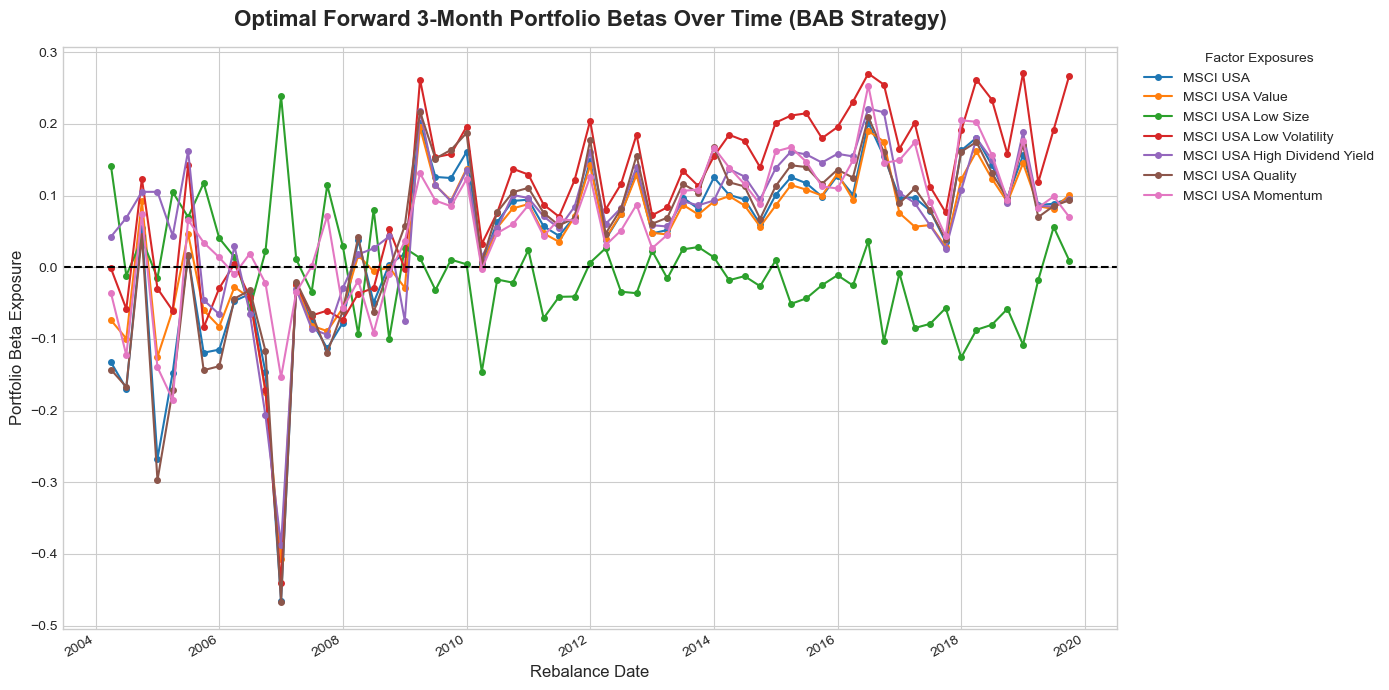

In [43]:
import matplotlib.pyplot as plt

# Set a clean style for the plot
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot all columns in the dataframe
for column in df_target_betas.columns:
    # Clean up the label for the legend (e.g., replacing 'Port_Beta_MSCI USA' with 'Market')
    label_name = column.replace('Port_Beta_', '') 
    ax.plot(df_target_betas.index, df_target_betas[column], marker='o', markersize=4, label=label_name)

# Formatting the plot
ax.set_title('Optimal Forward 3-Month Portfolio Betas Over Time (BAB Strategy)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Rebalance Date', fontsize=12)
ax.set_ylabel('Portfolio Beta Exposure', fontsize=12)

# Add a horizontal line at 0 for reference
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Place the legend outside the plot so it doesn't cover your data
ax.legend(title='Factor Exposures', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Automatically format the x-axis dates to look nice
fig.autofmt_xdate()

# Adjust layout to prevent the legend from being cut off
plt.tight_layout()
plt.show()

Average 'Perfect Foresight' Sharpe Ratio: 2.54
Average 3-Month Return: 28.01%


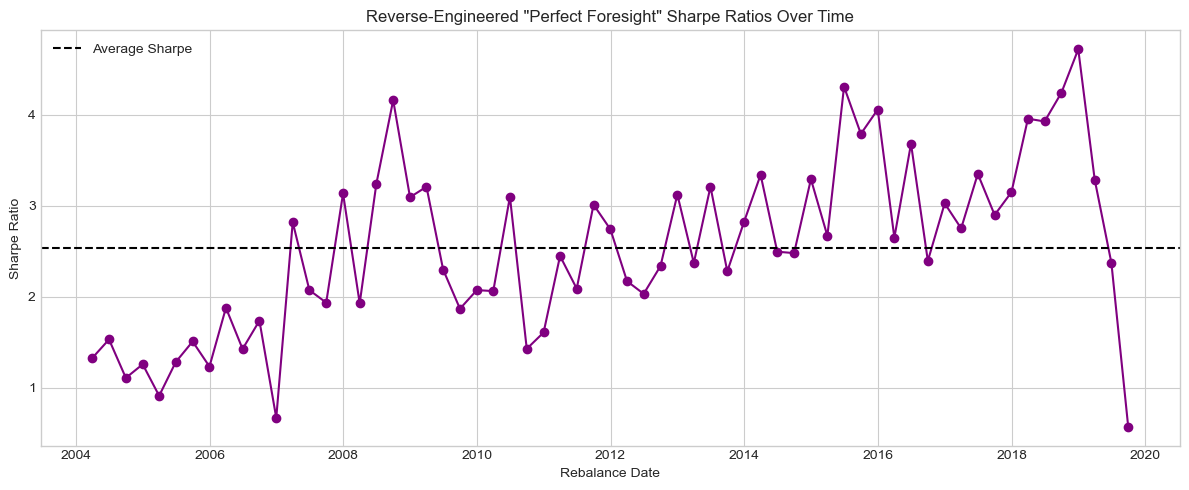


Quarterly Breakdown:


,Forward_3M_Return,Annualized_Vol,Sharpe_Ratio
2004-03-31,0.413099,0.305057,1.329129
2004-06-30,0.390455,0.247854,1.532255
2004-09-30,0.311719,0.271387,1.109635
2004-12-31,0.297197,0.227379,1.259234
2005-03-31,0.208281,0.216932,0.913293


In [38]:
# Let's reverse engineer Sharpe ratios that we get

# Create a dictionary to store our reverse-engineered metrics
realized_metrics = {}

for date_t in df_target_weights.index:
    # 1. Get the optimal weights for this specific quarter and drop the NaNs 
    # (NaNs represent stocks that weren't active or valid in this specific quarter)
    w = df_target_weights.loc[date_t].dropna()
    valid_tickers = w.index.tolist()

    # 2. Re-locate the exact forward 3-month window
    past_dates = returns.index[returns.index <= date_t] # Change 'returns' to 'returns_df' if that's your variable name
    idx_t = returns.index.get_loc(past_dates[-1])
    
    # Ensure we don't go out of bounds at the end of the dataset
    if idx_t + 3 >= len(returns.index):
        continue
        
    forward_dates = returns.index[idx_t+1 : idx_t+4]

    # 3. Re-calculate the exact math the optimizer used
    # Forward cumulative returns
    forward_returns = (1 + returns.loc[forward_dates, valid_tickers]).prod() - 1
    
    # Trailing 60m Annualized Covariance
    cov_matrix = returns.loc[:date_t].tail(60)[valid_tickers].cov() * 12
    
    # Forward cumulative Risk-Free rate
    forward_rates = df_rf['DGS10'].reindex(forward_dates, method='ffill')
    rf_forward = (1 + (forward_rates / 100 / 12)).prod() - 1

    # 4. Calculate the resulting Portfolio Return, Volatility, and Sharpe
    port_return = np.dot(w, forward_returns)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) 
    
    # The exact Sharpe ratio the optimizer was trying to maximize
    sharpe = (port_return - rf_forward) / (port_vol + 1e-9)
    
    realized_metrics[date_t] = {
        'Forward_3M_Return': port_return,
        'Annualized_Vol': port_vol,
        'Sharpe_Ratio': sharpe
    }

# Convert to a DataFrame for easy viewing
df_sanity_check = pd.DataFrame(realized_metrics).T

# Print the average Sharpe across the whole backtest
print(f"Average 'Perfect Foresight' Sharpe Ratio: {df_sanity_check['Sharpe_Ratio'].mean():.2f}")
print(f"Average 3-Month Return: {df_sanity_check['Forward_3M_Return'].mean() * 100:.2f}%")

# Let's plot it to see how the optimizer navigated different market regimes!
plt.figure(figsize=(12, 5))
plt.plot(df_sanity_check.index, df_sanity_check['Sharpe_Ratio'], marker='o', color='purple')
plt.axhline(df_sanity_check['Sharpe_Ratio'].mean(), color='black', linestyle='--', label='Average Sharpe')
plt.title('Reverse-Engineered "Perfect Foresight" Sharpe Ratios Over Time')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Rebalance Date')
plt.legend()
plt.tight_layout()
plt.show()

# Display the first few rows
print("\nQuarterly Breakdown:")
display(df_sanity_check.head())

In [44]:
# Without BAB Scenario

# Rebalancing dates
quarterly_dates = pd.date_range(start='2004-01-31', end='2019-09-30', freq='Q')

# Create lists to hold our target data
target_weights_list = []
target_betas_list = []

# Loop through your quarterly rebalance dates
for date in quarterly_dates:
    weights, port_betas = beta_optimizer(
        date_t=date, 
        constituents=sp500_constituents[date], 
        returns_df=returns, 
        betas_dict=all_equities_betas, 
        rf_df=df_rf,
        bab_scenario=False, # Toggle True/False based on your desired dataset
        gross_exposure=1.6, 
        net_exposure=0.6
    )
    
    if weights is not None:
        # Tag the date so we can merge it with our feature set later
        weights.name = date
        port_betas.name = date
        
        target_weights_list.append(weights)
        target_betas_list.append(port_betas)

# Combine into master DataFrames
df_target_weights = pd.DataFrame(target_weights_list)
df_target_betas = pd.DataFrame(target_betas_list)

df_target_betas

C:\Users\Anas\AppData\Local\Temp\ipykernel_39592\3236854842.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_dates = pd.date_range(start='2004-01-31', end='2019-09-30', freq='Q')


2007-03-31: Optimization Failed - Positive directional derivative for linesearch
2007-12-31: Optimization Failed - Iteration limit reached
2011-06-30: Optimization Failed - Inequality constraints incompatible
2013-06-30: Optimization Failed - Iteration limit reached
2014-09-30: Optimization Failed - Iteration limit reached
2014-12-31: Optimization Failed - Iteration limit reached
2015-03-31: Optimization Failed - Iteration limit reached
2015-09-30: Optimization Failed - Inequality constraints incompatible
2016-03-31: Optimization Failed - Iteration limit reached
2017-12-31: Optimization Failed - Iteration limit reached
2019-03-31: Optimization Failed - Iteration limit reached


,Port_Beta_MSCI USA,Port_Beta_MSCI USA Value,Port_Beta_MSCI USA Low Size,Port_Beta_MSCI USA Low Volatility,Port_Beta_MSCI USA High Dividend Yield,Port_Beta_MSCI USA Quality,Port_Beta_MSCI USA Momentum
2004-03-31,0.099731,0.113348,0.051336,0.184335,0.139308,0.107497,0.091074
2004-06-30,0.036981,0.043341,-0.019858,0.069220,0.060165,0.038247,0.041916
2004-09-30,0.043476,0.052142,-0.003195,0.068663,0.057673,0.040458,0.039084
2004-12-31,0.046475,0.038137,-0.019653,0.057558,0.053823,0.051378,0.025072
2005-03-31,0.015905,0.008963,-0.028858,0.008949,0.009939,0.021557,0.007527
2005-06-30,0.029802,0.024380,-0.015468,0.037081,0.026826,0.032374,0.027837
2005-09-30,0.028441,0.030215,0.020061,0.045732,0.045080,0.031766,0.025022
2005-12-31,0.034062,0.031302,-0.014308,0.046237,0.052678,0.038192,0.021841
2006-03-31,0.034592,0.037412,0.000163,0.046747,0.050921,0.031851,0.013627
2006-06-30,0.021824,0.019596,-0.003667,0.029955,0.017650,0.028089,0.016502


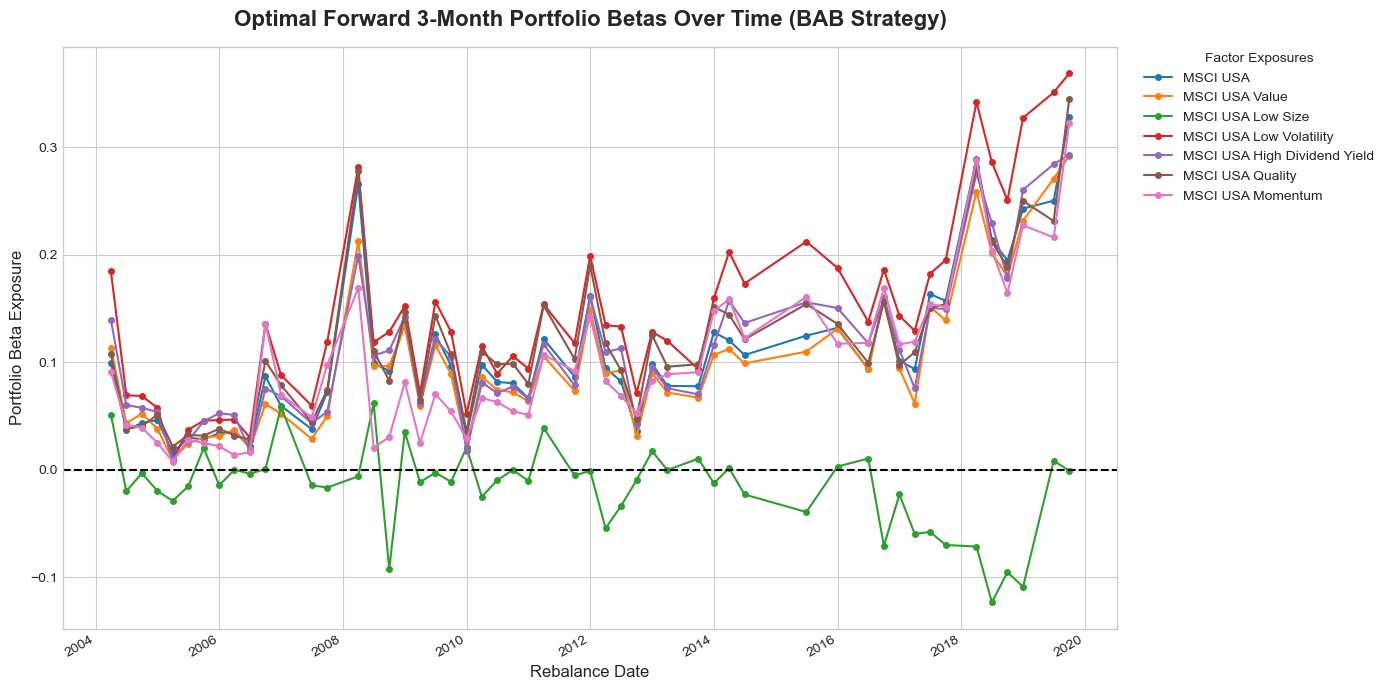

In [45]:
import matplotlib.pyplot as plt

# Set a clean style for the plot
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot all columns in the dataframe
for column in df_target_betas.columns:
    # Clean up the label for the legend (e.g., replacing 'Port_Beta_MSCI USA' with 'Market')
    label_name = column.replace('Port_Beta_', '') 
    ax.plot(df_target_betas.index, df_target_betas[column], marker='o', markersize=4, label=label_name)

# Formatting the plot
ax.set_title('Optimal Forward 3-Month Portfolio Betas Over Time (BAB Strategy)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Rebalance Date', fontsize=12)
ax.set_ylabel('Portfolio Beta Exposure', fontsize=12)

# Add a horizontal line at 0 for reference
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Place the legend outside the plot so it doesn't cover your data
ax.legend(title='Factor Exposures', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Automatically format the x-axis dates to look nice
fig.autofmt_xdate()

# Adjust layout to prevent the legend from being cut off
plt.tight_layout()
plt.show()

Average 'Perfect Foresight' Sharpe Ratio: 2.94
Average 3-Month Return: 11.56%


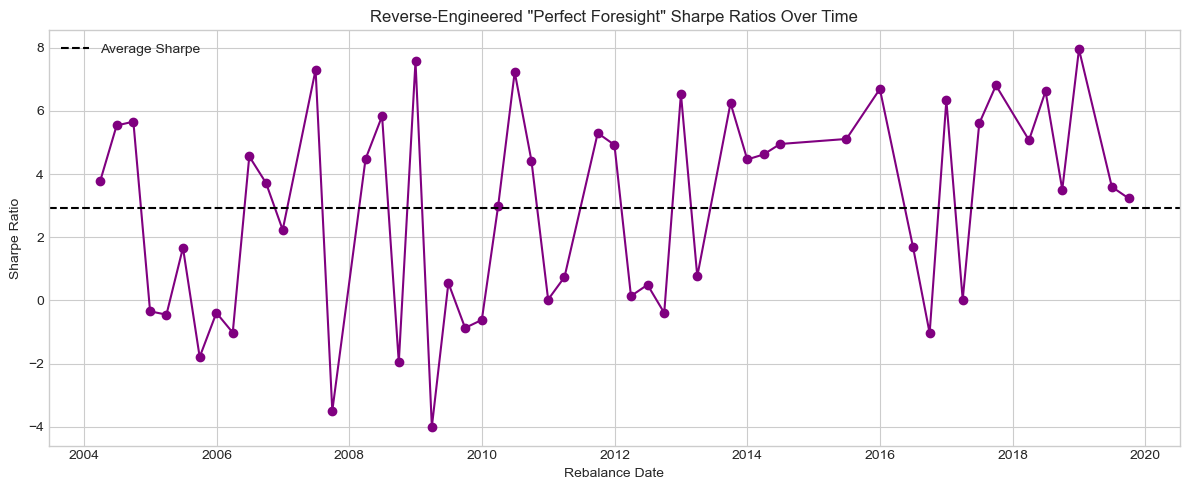


Quarterly Breakdown:


,Forward_3M_Return,Annualized_Vol,Sharpe_Ratio
2004-03-31,0.178109,0.045184,3.772820
2004-06-30,0.183919,0.031262,5.541538
2004-09-30,0.145804,0.023886,5.661282
2004-12-31,-0.000261,0.032291,-0.344775
2005-03-31,-0.000882,0.024470,-0.451216


In [46]:
# Let's reverse engineer Sharpe ratios that we get

# Create a dictionary to store our reverse-engineered metrics
realized_metrics = {}

for date_t in df_target_weights.index:
    # 1. Get the optimal weights for this specific quarter and drop the NaNs 
    # (NaNs represent stocks that weren't active or valid in this specific quarter)
    w = df_target_weights.loc[date_t].dropna()
    valid_tickers = w.index.tolist()

    # 2. Re-locate the exact forward 3-month window
    past_dates = returns.index[returns.index <= date_t] # Change 'returns' to 'returns_df' if that's your variable name
    idx_t = returns.index.get_loc(past_dates[-1])
    
    # Ensure we don't go out of bounds at the end of the dataset
    if idx_t + 3 >= len(returns.index):
        continue
        
    forward_dates = returns.index[idx_t+1 : idx_t+4]

    # 3. Re-calculate the exact math the optimizer used
    # Forward cumulative returns
    forward_returns = (1 + returns.loc[forward_dates, valid_tickers]).prod() - 1
    
    # Trailing 60m Annualized Covariance
    cov_matrix = returns.loc[:date_t].tail(60)[valid_tickers].cov() * 12
    
    # Forward cumulative Risk-Free rate
    forward_rates = df_rf['DGS10'].reindex(forward_dates, method='ffill')
    rf_forward = (1 + (forward_rates / 100 / 12)).prod() - 1

    # 4. Calculate the resulting Portfolio Return, Volatility, and Sharpe
    port_return = np.dot(w, forward_returns)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) 
    
    # The exact Sharpe ratio the optimizer was trying to maximize
    sharpe = (port_return - rf_forward) / (port_vol + 1e-9)
    
    realized_metrics[date_t] = {
        'Forward_3M_Return': port_return,
        'Annualized_Vol': port_vol,
        'Sharpe_Ratio': sharpe
    }

# Convert to a DataFrame for easy viewing
df_sanity_check = pd.DataFrame(realized_metrics).T

# Print the average Sharpe across the whole backtest
print(f"Average 'Perfect Foresight' Sharpe Ratio: {df_sanity_check['Sharpe_Ratio'].mean():.2f}")
print(f"Average 3-Month Return: {df_sanity_check['Forward_3M_Return'].mean() * 100:.2f}%")

# Let's plot it to see how the optimizer navigated different market regimes!
plt.figure(figsize=(12, 5))
plt.plot(df_sanity_check.index, df_sanity_check['Sharpe_Ratio'], marker='o', color='purple')
plt.axhline(df_sanity_check['Sharpe_Ratio'].mean(), color='black', linestyle='--', label='Average Sharpe')
plt.title('Reverse-Engineered "Perfect Foresight" Sharpe Ratios Over Time')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Rebalance Date')
plt.legend()
plt.tight_layout()
plt.show()

# Display the first few rows
print("\nQuarterly Breakdown:")
display(df_sanity_check.head())

In [53]:
# Let's test the reverse-BAB (long high beta and short small beta)
# Let's set-up the optimization function
def reverse_bab_beta_optimizer(
    date_t, constituents, returns_df, betas_dict, rf_df,
    reverse_bab_scenario=True, gross_exposure=2.0, net_exposure=0.0
):
    # 1. BULLETPROOF FORWARD DATES
    # Find the exact row index for the most recent trading day on or before date_t
    past_dates = returns_df.index[returns_df.index <= date_t]
    if len(past_dates) == 0:
        return None, None
        
    idx_t = returns_df.index.get_loc(past_dates[-1])
    
    # Grab exactly the next 3 rows (months) based on integer positioning
    if idx_t + 3 >= len(returns_df.index):
        return None, None
        
    forward_dates = returns_df.index[idx_t+1 : idx_t+4]

    # Filter constituents
    valid_tickers = [
        tic for tic in constituents 
        if tic in returns_df.columns 
        and returns_df[tic].loc[:date_t].count() >= 60
        and returns_df[tic].loc[forward_dates].count() == 3
    ]
    
    if not valid_tickers:
        print(f"{date_t.date()}: Skipped - No valid tickers with enough history.")
        return None, None

    # 2. Setup Data Inputs
    forward_returns = (1 + returns_df.loc[forward_dates, valid_tickers]).prod() - 1
    cov_matrix = returns_df.loc[:date_t].tail(60)[valid_tickers].cov() * 12
    
    forward_rates = rf_df['DGS10'].reindex(forward_dates, method='ffill')
    rf_forward = (1 + (forward_rates / 100 / 12)).prod() - 1

    current_betas = {}
    for tic in valid_tickers:
        current_betas[tic] = betas_dict[tic].loc[:date_t].iloc[-1]

    def negative_forward_sharpe(w):
        port_return = np.dot(w, forward_returns)
        port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) 
        return -(port_return - rf_forward) / (port_vol + 1e-9)

    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - net_exposure},
        {'type': 'ineq', 'fun': lambda w: gross_exposure - np.sum(np.abs(w))}
    ]
    
    bounds = []
    long_idx = []
    short_idx = []
    
    for i, tic in enumerate(valid_tickers):
        beta_market = current_betas[tic]['Beta_MSCI USA']
        if reverse_bab_scenario:
            if beta_market < 1.0:
                bounds.append((0.0, gross_exposure))
                long_idx.append(i)
            else:
                bounds.append((-gross_exposure, 0.0))
                short_idx.append(i)
        else:
            bounds.append((-gross_exposure, gross_exposure))

    # 3. SMART INITIAL GUESS
    # Prevent the optimizer from starting at 0.0 to avoid np.abs() gradient failures
    init_guess = np.zeros(len(valid_tickers))
    if reverse_bab_scenario and len(long_idx) > 0 and len(short_idx) > 0:
        # Start exactly at a feasible point (100% long side, 100% short side)
        init_guess[long_idx] = 1.0 / len(long_idx)
        init_guess[short_idx] = -1.0 / len(short_idx)
    else:
        init_guess.fill(net_exposure / len(valid_tickers))

    # 4. Run Optimizer
    result = minimize(
        negative_forward_sharpe, init_guess, method='SLSQP', 
        bounds=bounds, constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-6}
    )
    
    # We added print statements here so it doesn't fail silently anymore!
    if not result.success:
        print(f"{date_t.date()}: Optimization Failed - {result.message}")
        return None, None
        
    reverse_bab_optimal_weights = pd.Series(result.x, index=valid_tickers)
    
    reverse_bab_portfolio_betas = {}
    factor_cols = current_betas[valid_tickers[0]].index 
    for factor in factor_cols:
        reverse_bab_port_beta = sum(reverse_bab_optimal_weights[tic] * current_betas[tic][factor] for tic in valid_tickers)
        reverse_bab_portfolio_betas[f'Port_{factor}'] = reverse_bab_port_beta

    return reverse_bab_optimal_weights, pd.Series(reverse_bab_portfolio_betas)

In [54]:
# Rebalancing dates
quarterly_dates = pd.date_range(start='2004-01-31', end='2019-09-30', freq='Q')

# Create lists to hold our target data
reverse_bab_target_weights_list = []
reverse_bab_target_betas_list = []

# Loop through your quarterly rebalance dates
for date in quarterly_dates:
    reverse_bab_weights, reverse_bab_port_betas = reverse_bab_beta_optimizer(
        date_t=date, 
        constituents=sp500_constituents[date], 
        returns_df=returns, 
        betas_dict=all_equities_betas, 
        rf_df=df_rf,
        reverse_bab_scenario=True, # Toggle True/False based on your desired dataset
        gross_exposure=1.6, 
        net_exposure=0.6
    )
    
    if reverse_bab_weights is not None:
        # Tag the date so we can merge it with our feature set later
        reverse_bab_weights.name = date
        reverse_bab_port_betas.name = date
        
        reverse_bab_target_weights_list.append(reverse_bab_weights)
        reverse_bab_target_betas_list.append(reverse_bab_port_betas)

# Combine into master DataFrames
df_reverse_bab_target_weights = pd.DataFrame(reverse_bab_target_weights_list)
df_reverse_bab_target_betas = pd.DataFrame(reverse_bab_target_betas_list)

df_reverse_bab_target_betas

C:\Users\Anas\AppData\Local\Temp\ipykernel_39592\1617353857.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_dates = pd.date_range(start='2004-01-31', end='2019-09-30', freq='Q')


,Port_Beta_MSCI USA,Port_Beta_MSCI USA Value,Port_Beta_MSCI USA Low Size,Port_Beta_MSCI USA Low Volatility,Port_Beta_MSCI USA High Dividend Yield,Port_Beta_MSCI USA Quality,Port_Beta_MSCI USA Momentum
2004-03-31,-0.132546,-0.073829,0.141918,-0.001461,0.042475,-0.142849,-0.035766
2004-06-30,-0.169341,-0.099577,-0.011701,-0.058226,0.068861,-0.167001,-0.122811
2004-09-30,0.054129,0.092171,0.039286,0.123441,0.105141,0.043556,0.073891
2004-12-31,-0.267356,-0.125079,-0.015127,-0.029707,0.105180,-0.297239,-0.139526
2005-03-31,-0.146927,-0.059921,0.105025,-0.060575,0.043901,-0.171797,-0.185043
...,...,...,...,...,...,...,...
2018-09-30,0.096849,0.090964,-0.058022,0.157767,0.090245,0.095271,0.094017
2018-12-31,0.156060,0.145086,-0.108212,0.270419,0.188113,0.171038,0.176604
2019-03-31,0.086844,0.085095,-0.017741,0.118562,0.085513,0.069938,0.083251
2019-06-30,0.088558,0.081284,0.056084,0.192010,0.084747,0.085538,0.098758


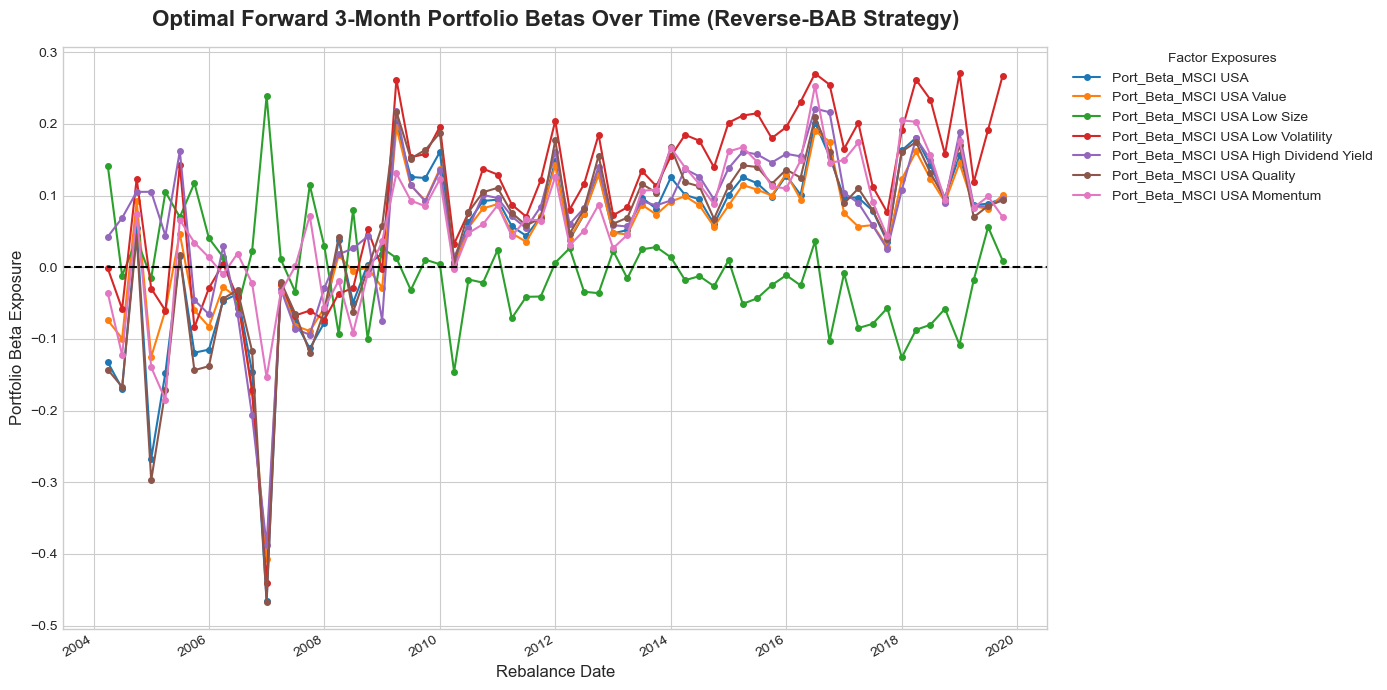

In [55]:
import matplotlib.pyplot as plt

# Set a clean style for the plot
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot all columns in the dataframe
for column in df_reverse_bab_target_betas.columns:
    # Clean up the label for the legend (e.g., replacing 'Port_Beta_MSCI USA' with 'Market')
    label_name = column.replace('Port_Reverse_BAB_Beta_', '') 
    ax.plot(df_reverse_bab_target_betas.index, df_reverse_bab_target_betas[column], marker='o', markersize=4, label=label_name)

# Formatting the plot
ax.set_title('Optimal Forward 3-Month Portfolio Betas Over Time (Reverse-BAB Strategy)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Rebalance Date', fontsize=12)
ax.set_ylabel('Portfolio Beta Exposure', fontsize=12)

# Add a horizontal line at 0 for reference
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Place the legend outside the plot so it doesn't cover your data
ax.legend(title='Factor Exposures', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Automatically format the x-axis dates to look nice
fig.autofmt_xdate()

# Adjust layout to prevent the legend from being cut off
plt.tight_layout()
plt.show()

Average 'Perfect Foresight' Sharpe Ratio: 2.94
Average 3-Month Return: 11.56%


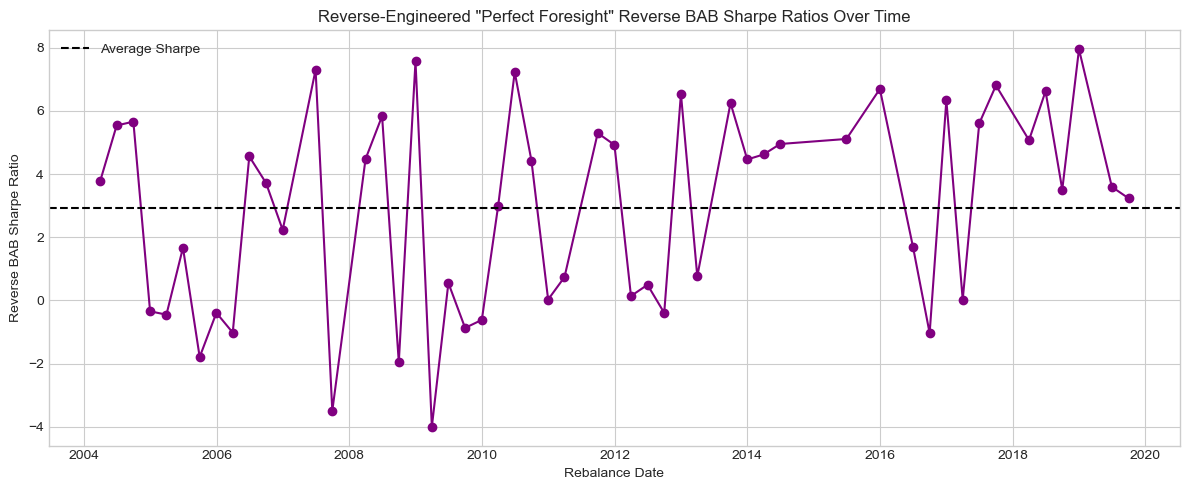


Quarterly Breakdown:


,Forward_3M_Return,Annualized_Vol,Sharpe_Ratio
2004-03-31,0.178109,0.045184,3.772820
2004-06-30,0.183919,0.031262,5.541538
2004-09-30,0.145804,0.023886,5.661282
2004-12-31,-0.000261,0.032291,-0.344775
2005-03-31,-0.000882,0.024470,-0.451216


In [59]:
# Let's reverse engineer Sharpe ratios that we get

# Create a dictionary to store our reverse-engineered metrics
reverse_bab_realized_metrics = {}

for date_t in df_reverse_bab_target_weights.index:
    # 1. Get the optimal weights for this specific quarter and drop the NaNs 
    # (NaNs represent stocks that weren't active or valid in this specific quarter)
    w = df_reverse_bab_target_weights.loc[date_t].dropna()
    valid_tickers = w.index.tolist()

    # 2. Re-locate the exact forward 3-month window
    past_dates = returns.index[returns.index <= date_t] # Change 'returns' to 'returns_df' if that's your variable name
    idx_t = returns.index.get_loc(past_dates[-1])
    
    # Ensure we don't go out of bounds at the end of the dataset
    if idx_t + 3 >= len(returns.index):
        continue
        
    forward_dates = returns.index[idx_t+1 : idx_t+4]

    # 3. Re-calculate the exact math the optimizer used
    # Forward cumulative returns
    forward_returns = (1 + returns.loc[forward_dates, valid_tickers]).prod() - 1
    
    # Trailing 60m Annualized Covariance
    cov_matrix = returns.loc[:date_t].tail(60)[valid_tickers].cov() * 12
    
    # Forward cumulative Risk-Free rate
    forward_rates = df_rf['DGS10'].reindex(forward_dates, method='ffill')
    rf_forward = (1 + (forward_rates / 100 / 12)).prod() - 1

    # 4. Calculate the resulting Portfolio Return, Volatility, and Sharpe
    reverse_bab_port_return = np.dot(w, forward_returns)
    reverse_bab_port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) 
    
    # The exact Sharpe ratio the optimizer was trying to maximize
    reverse_bab_sharpe = (reverse_bab_port_return - rf_forward) / (reverse_bab_port_vol + 1e-9)
    
    reverse_bab_realized_metrics[date_t] = {
        'Forward_3M_Return': reverse_bab_port_return,
        'Annualized_Vol': reverse_bab_port_vol,
        'Sharpe_Ratio': reverse_bab_sharpe
    }

# Convert to a DataFrame for easy viewing
df_reverse_bab_sanity_check = pd.DataFrame(realized_metrics).T

# Print the average Sharpe across the whole backtest
print(f"Average 'Perfect Foresight' Sharpe Ratio: {df_reverse_bab_sanity_check['Sharpe_Ratio'].mean():.2f}")
print(f"Average 3-Month Return: {df_reverse_bab_sanity_check['Forward_3M_Return'].mean() * 100:.2f}%")

# Let's plot it to see how the optimizer navigated different market regimes!
plt.figure(figsize=(12, 5))
plt.plot(df_reverse_bab_sanity_check.index, df_reverse_bab_sanity_check['Sharpe_Ratio'], marker='o', color='purple')
plt.axhline(df_sanity_check['Sharpe_Ratio'].mean(), color='black', linestyle='--', label='Average Sharpe')
plt.title('Reverse-Engineered "Perfect Foresight" Reverse BAB Sharpe Ratios Over Time')
plt.ylabel('Reverse BAB Sharpe Ratio')
plt.xlabel('Rebalance Date')
plt.legend()
plt.tight_layout()
plt.show()

# Display the first few rows
print("\nQuarterly Breakdown:")
display(df_reverse_bab_sanity_check.head())